In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("houses_messy.csv")

In [3]:
#观察样本
print(df.shape)#1200,8
print(df.head())
print(df.info())#price,neighborhood是object
print(df.isna().sum())#缺失值
print(df.describe())



(1200, 8)
   area_sqm  bedrooms  bathrooms  age_years neighborhood  has_garage  \
0     120.7         3        1.0         45    Riverside           1   
1      73.6         2        1.0          5      Oldtown           1   
2     136.3         4        NaN         35     Eastgate           1   
3     142.9         4        2.0         20   Greenfield           0   
4      41.7         1        1.0         22    RIVERSIDE           1   

   distance_to_center_km price_k  
0                    8.9   444.5  
1                    3.6   251.0  
2                   13.3   410.6  
3                   10.1   507.3  
4                   15.7   160.5  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   area_sqm               1140 non-null   float64
 1   bedrooms               1200 non-null   int64  
 2   bathrooms              1104 

In [4]:
#price_k去除k
df_clean=df.copy()
df_clean['price_k']=(
    df_clean['price_k']
    .astype(str)
    .str.strip()
    .str.replace('k','',case=False,regex=False)
)
df_clean['price_k']=pd.to_numeric(df_clean['price_k'],errors='coerce')
#检查一下有没有空
print(df_clean['price_k'].isnull().any())

False


In [5]:
#统一neighborhood格式
df_clean['neighborhood']=(
    df_clean['neighborhood']
    .astype('string')
    .str.strip()
    .str.lower()
)
#检查
df_clean['neighborhood'].nunique()

5

In [6]:
df_clean.loc[df_clean['age_years']>100,'age_years']=np.nan
df_clean=df_clean.dropna(subset=['price_k'])
q1=df_clean['price_k'].quantile(0.25)
q3=df_clean['price_k'].quantile(0.75)
iqr=q3-q1
lower=q1-1.5*iqr
upper=q3+1.5*iqr
df_clean=df_clean[
    (df_clean['price_k']>=lower)&
    (df_clean['price_k']<=upper)
]
df_clean

,area_sqm,bedrooms,bathrooms,age_years,neighborhood,has_garage,distance_to_center_km,price_k
0,120.7,3,1.0,45.0,riverside,1,8.9,444.5
1,73.6,2,1.0,5.0,oldtown,1,3.6,251.0
2,136.3,4,NaN,35.0,eastgate,1,13.3,410.6
3,142.9,4,2.0,20.0,greenfield,0,10.1,507.3
4,41.7,1,1.0,22.0,riverside,1,15.7,160.5
...,...,...,...,...,...,...,...,...
1195,178.6,4,3.0,36.0,oldtown,1,NaN,561.3
1196,67.0,2,1.0,46.0,greenfield,0,4.6,195.3
1197,77.6,2,1.0,7.0,hillview,1,10.2,298.5
1198,NaN,4,NaN,2.0,oldtown,0,1.3,654.2


In [7]:
num_cols=[
    'area_sqm',
    'bedrooms',
    'bathrooms',
    'age_years',
    'distance_to_center_km'
]
for col in num_cols:
    df_clean[col]=df_clean[col].fillna(df_clean[col].median())
df_clean['neighborhood']=df_clean['neighborhood'].fillna(
    df_clean['neighborhood'].mode()[0]
)
df_clean.isna().sum()


area_sqm                 0
bedrooms                 0
bathrooms                0
age_years                0
neighborhood             0
has_garage               0
distance_to_center_km    0
price_k                  0
dtype: int64

In [8]:
#机器学习部分
#标准化
df1=df_clean.copy()
continuous_cols=num_cols
means=df1[continuous_cols].mean(axis=0)
stds=df1[continuous_cols].std(axis=0)
for col in continuous_cols:
    df1[col]=(df1[col]-df1[col].mean())/df1[col].std()
df1=pd.get_dummies(df1,columns=['neighborhood'],dtype=int,drop_first=True)


In [9]:
Y=df1['price_k'].values
X=df1.drop(['price_k'],axis=1).values
X[0,:]

array([ 0.36740332, -0.05367039, -0.99221441,  0.92736723,  1.        ,
        0.14101294,  0.        ,  0.        ,  0.        ,  1.        ])

In [10]:
#扩充矩阵
m=X.shape[0]
X=np.hstack((np.ones((m,1)),X))
#注意不要手贱运行多次

In [11]:
n=X.shape[1]
X[0,:]

array([ 1.        ,  0.36740332, -0.05367039, -0.99221441,  0.92736723,
        1.        ,  0.14101294,  0.        ,  0.        ,  0.        ,
        1.        ])

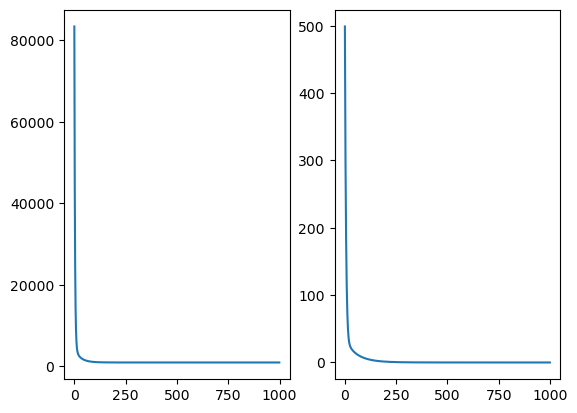

In [12]:

alpha=0.1
n_iters=1000
cost_history=[]
grad_history=[]
w=np.zeros((n,))
for i in range(n_iters):
    pred=X@w
    err=pred-Y
    grad=(X.T@err)/m
    w=w-alpha*grad
    cost_history.append(((err**2).mean())/2)
    grad_history.append(np.linalg.norm(grad))


fig,axes=plt.subplots(1,2)
ax1=axes[0]
ax2=axes[1]
ax1.plot(range(n_iters),cost_history)
ax2.plot(range(n_iters),grad_history)

In [13]:
w[0]

329.2057720683223

In [14]:
w[1:]
w[[0,1,2,3,5]]

array([329.20577207, 104.5914078 ,  24.26403852,   3.05702509,
        15.13097297])

In [15]:
w_original=w.copy()
intercept_scaled=w[0]
coef_scaled=w[1:].copy()
coef_original=coef_scaled.copy()
coef_original[[0,1,2,3,5]]=(coef_original[[0,1,2,3,5]]/stds)
intercept_original=intercept_scaled-np.sum(
    coef_scaled[[0,1,2,3,5]]*means/stds
)

In [16]:
w_original = np.hstack([
    intercept_original,
    coef_original
])

In [17]:
w_original

array([ -6.48257518,   3.22943197,  21.05023854,   4.84987088,
        -1.73499832,  15.13097297,  -4.56298063,  12.61122665,
        82.42565416,  51.3731799 , 107.4130331 ])

In [18]:
feature_names = df1.drop("price_k", axis=1).columns.tolist()
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": w_original[1:]
})
coef_df,w_original[0]

(                   feature        coef
 0                 area_sqm    3.229432
 1                 bedrooms   21.050239
 2                bathrooms    4.849871
 3                age_years   -1.734998
 4               has_garage   15.130973
 5    distance_to_center_km   -4.562981
 6  neighborhood_greenfield   12.611227
 7    neighborhood_hillview   82.425654
 8     neighborhood_oldtown   51.373180
 9   neighborhood_riverside  107.413033,
 -6.482575175794636)